In [16]:
import torch
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
# build dataset
words = open('../data/names.txt', 'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [7]:
# Vocabulary
chars = sorted(list(set(''.join(words))))
# We have a mapping for all characters
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0

itos = {i:s for s,i in stoi.items()}

vocab_size = len(stoi)

In [13]:
block_size = 3

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop context and append in a rolling window

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

random.seed(42)

random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

X_train, Y_train = build_dataset(words[:n1])
X_val, Y_val = build_dataset(words[n1:n2])
X_test, Y_test = build_dataset(words[n2:])

torch.Size([182441, 3]) torch.Size([182441])
torch.Size([22902, 3]) torch.Size([22902])
torch.Size([22803, 3]) torch.Size([22803])


In [ ]:
# initialize params

embedding_size = 10
hidden_layer = 200

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, embedding_size),                generator = g)
W1 = torch.randn((block_size * embedding_size, hidden_layer), generator = g)
b1 = torch.randn(hidden_layer,                                generator = g)
W2 = torch.randn((hidden_layer, vocab_size),                  
                 generator = g) * 0.01 # allows to reduce the initial loss 
b2 = torch.randn(vocab_size,                                  
                 generator = g) * 0 # to reduce the output logits bias

parameters = [C, W1, b1, W2, b2]

print(sum(p.nelement() for p in parameters)) # total params

for p in parameters:
    p.requires_grad = True

11897


In [98]:
max_steps = 200000
batch_size = 256

# gradient descent
losses = []

lr = 0.1 / 0.9

for k in range(max_steps):
    # minibatch
    ix = torch.randint(0, X_train.shape[0], (batch_size,))
    Xb, Yb = X_train[ix], Y_train[ix]

    # Forward pass
    emb = C[Xb]
    emb_size = emb.shape[0]
    embcat = emb.view(emb_size, -1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = (h @ W2) + b2
    loss = F.cross_entropy(logits, Yb)

    # backwards pass
    for parameter in parameters:
        parameter.grad = None
    loss.backward()

    # update lr

    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if k % 10000 == 0:
        lr *= 0.75
        print(f'{k:7d} /{max_steps:7d}: {loss.item():.4f} {lr:.4f}')

    losses.append(loss.log10().item())

      0 / 200000: 3.2958 0.0833
  10000 / 200000: 2.0188 0.0625
  20000 / 200000: 2.1753 0.0469
  30000 / 200000: 2.0026 0.0352
  40000 / 200000: 2.3712 0.0264
  50000 / 200000: 2.2014 0.0198
  60000 / 200000: 2.1270 0.0148
  70000 / 200000: 2.0105 0.0111
  80000 / 200000: 2.0698 0.0083
  90000 / 200000: 1.9507 0.0063
 100000 / 200000: 2.1212 0.0047
 110000 / 200000: 2.1611 0.0035
 120000 / 200000: 2.1175 0.0026
 130000 / 200000: 2.1312 0.0020
 140000 / 200000: 2.1129 0.0015
 150000 / 200000: 2.1102 0.0011
 160000 / 200000: 2.0567 0.0008
 170000 / 200000: 2.1136 0.0006
 180000 / 200000: 2.0852 0.0005
 190000 / 200000: 2.0871 0.0004


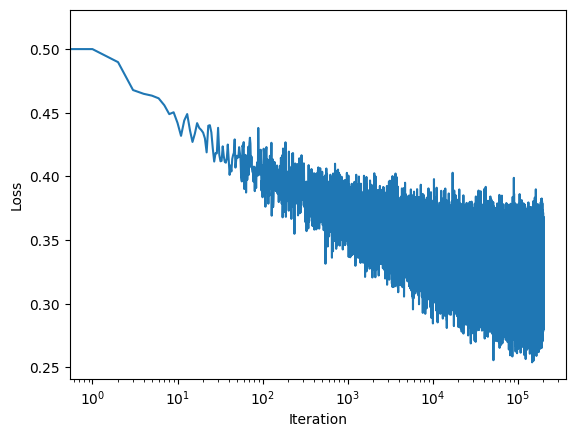

In [99]:
plt.plot(losses)
plt.xscale('log')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

In [100]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (X_train, Y_train),
        'val': (X_val, Y_val),
        'test': (X_test, Y_test)
    }[split]
    emb = C[x]
    emb_size = emb.shape[0]
    embcat = emb.view(emb_size, -1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = (h @ W2) + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.1058242321014404
val 2.152571201324463


In [101]:
g = torch.Generator().manual_seed(2147483647)

for _ in range(10):

    out = []
    context = [0] * block_size

    while True:
        # Forward pass
        embd = C[torch.tensor([context])]          
        h = torch.tanh(embd.view(1, -1) @ W1 + b1) 
        logits = h @ W2 + b2                      
        probs = F.softmax(logits, dim=1)

        # Sample next character
        ix = torch.multinomial(
            probs.squeeze(0),
            num_samples=1,
            generator=g
        ).item()

        out.append(itos[ix])

        if ix == 0:
            break

        # Slide the context window
        context = context[1:] + [ix]

    print(''.join(out))

cexza.
moal.
makileighannell.
imitta.
noluwan.
kata.
kreshiaubrithrison.
shiv.
jenan.
kinz.


(-0.5, 26.5, 0.5, -0.5)

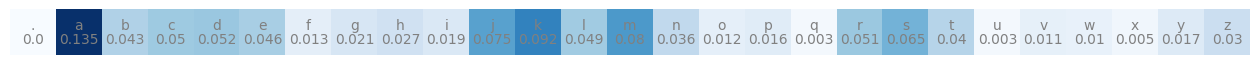

In [102]:
# Visualizing the output layer:
context = [0] * block_size

embd = C[torch.tensor([context])]          
h = torch.tanh(embd.view(1, -1) @ W1 + b1) 
logits = h @ W2 + b2                      
probs = F.softmax(logits, dim=1)

probs_np = probs.detach().numpy()

plt.figure(figsize=(16,2))
plt.imshow(probs_np, cmap='Blues')
for i in range(27):
    chstr = itos[i]
    plt.text(i, 0, chstr, ha="center", va="bottom", color='gray')
    plt.text(i, 0, round(probs_np[0][i], 3), ha="center", va="top", color='gray')

plt.axis('off')

In [103]:
# uniform distribution loss:
-torch.tensor(1/27.0).log()

tensor(3.2958)